# WAV, AAR и доступность поездок FHVHV

Период - январь 2025 - апрель 2026.

Основная сегментация состоит из трёх взаимоисключающих групп:

- `WAV request` - есть явный WAV-запрос, независимо от AAR и фактического WAV-мэтча;
- `AAR без WAV request` - поездка организована по AAR, но явного WAV-запроса нет;
- `Остальные` - нет ни WAV request, ни AAR.

WAV без явного запроса не считается признаком потребности пассажира в доступном автомобиле. Публичные TLC trip records содержат завершённые поездки, поэтому количество поездок используется как прокси реализованного спроса, а доля WAV-мэтчей не является полным fulfilment rate.

## 1. Настройки и загрузка витрин

In [5]:
from pathlib import Path
import warnings

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd()
MART_DIR = ROOT / 'data' / 'marts_product'
REFERENCE_DIR = ROOT / 'data' / 'reference'
ZONE_ZIP_PATH = REFERENCE_DIR / 'taxi_zones.zip'

MARTS = {
    'date_hour': MART_DIR / 'wav_v2_date_hour.parquet',
    'monthly': MART_DIR / 'wav_v2_monthly_metrics.parquet',
    'zones': MART_DIR / 'wav_v2_zone_metrics.parquet',
}
missing = [path.name for path in MARTS.values() if not path.exists()]
assert not missing, f'Не найдены витрины: {missing}.'

con = duckdb.connect()
con.execute("SET memory_limit = '4GB'")
con.execute('SET threads = 4')

date_hour = con.execute(
    'SELECT * FROM read_parquet(?)', [str(MARTS['date_hour'])]
).fetchdf()
monthly = con.execute(
    'SELECT * FROM read_parquet(?)', [str(MARTS['monthly'])]
).fetchdf()
zone_metrics = con.execute(
    'SELECT * FROM read_parquet(?)', [str(MARTS['zones'])]
).fetchdf()
con.close()

date_hour['date'] = pd.to_datetime(date_hour['date'])
monthly['month'] = pd.to_datetime(monthly['month'])

ACCESS_ORDER = ['WAV request', 'AAR без WAV request', 'Остальные']
ACCESS_COLORS = {
    'WAV request': '#1769e0',
    'AAR без WAV request': '#eb8a21',
    'Остальные': '#7b8794',
}

EXACT_ORDER = [
    'Не WAV, не AAR, не WAV request',
    'WAV без AAR и WAV request',
    'AAR без WAV и WAV request',
    'WAV request без WAV и AAR',
    'WAV + WAV request, не AAR',
    'AAR + WAV request, не WAV',
    'WAV + AAR, без WAV request',
    'WAV + AAR + WAV request',
]

assert set(date_hour['accessibility_segment']) == set(ACCESS_ORDER)
assert set(date_hour['exact_segment']).issubset(set(EXACT_ORDER))
assert date_hour['date'].nunique() == 485

display(pd.DataFrame({
    'период с': [date_hour['date'].min().date()],
    'период по': [date_hour['date'].max().date()],
    'календарных дней': [date_hour['date'].nunique()],
    'строк в дневно-часовой витрине': [len(date_hour)],
    'строк в месячной витрине': [len(monthly)],
    'зональных строк': [len(zone_metrics)],
}))

,период с,период по,календарных дней,строк в дневно-часовой витрине,строк в месячной витрине,зональных строк
0,2025-01-01,2026-04-30,485,118827,153,527


## 2. Восемь комбинаций WAV, AAR и WAV request

сегмент,поездки,"доля, %"
"Не WAV, не AAR, не WAV request","297,974,198",90.9994
WAV без AAR и WAV request,"28,248,412",8.6269
"WAV + WAV request, не AAR","888,958",0.2715
AAR без WAV и WAV request,"267,511",0.0817
WAV + AAR + WAV request,"38,426",0.0117
"WAV + AAR, без WAV request","28,791",0.0088
WAV request без WAV и AAR,11,0.0000
"AAR + WAV request, не WAV",0,0.0000


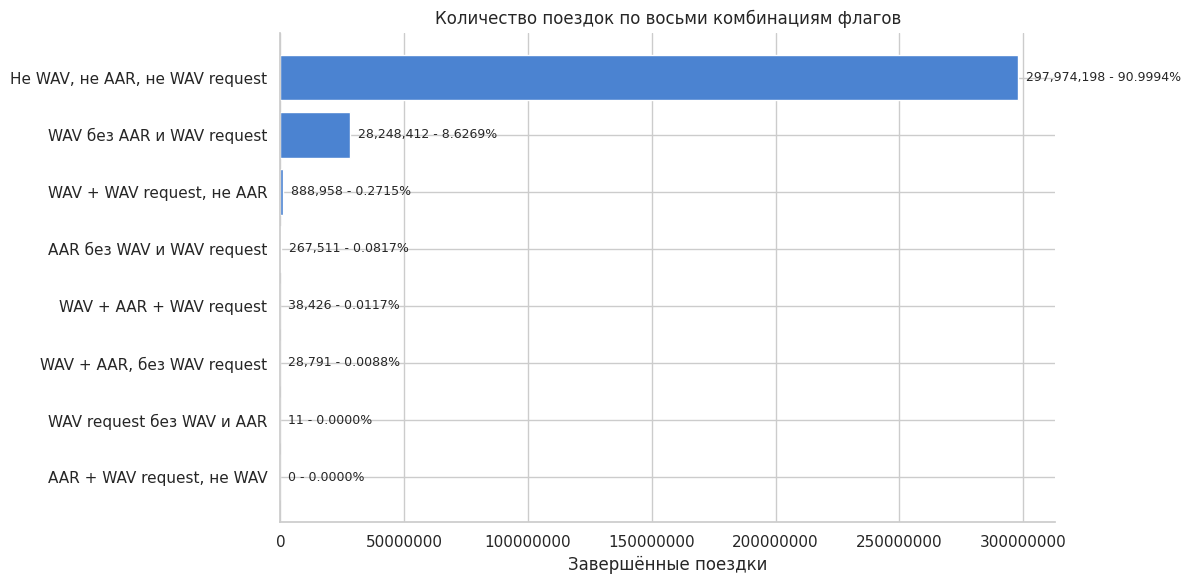

In [6]:
exact_counts = (
    date_hour.groupby('exact_segment')['trips'].sum()
    .reindex(EXACT_ORDER, fill_value=0)
    .rename_axis('сегмент')
    .rename('поездки')
    .reset_index()
)
exact_counts['доля, %'] = 100 * exact_counts['поездки'] / exact_counts['поездки'].sum()
exact_counts = exact_counts.sort_values('поездки', ascending=False).reset_index(drop=True)

display(
    exact_counts.style
    .format({'поездки': '{:,.0f}', 'доля, %': '{:.4f}'})
    .hide(axis='index')
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    exact_counts['сегмент'][::-1],
    exact_counts['поездки'][::-1],
    color='#4b83d1',
)
ax.set_title('Количество поездок по восьми комбинациям флагов')
ax.set_xlabel('Завершённые поездки')
ax.set_ylabel('')
ax.ticklabel_format(axis='x', style='plain')
for bar, (_, row) in zip(bars, exact_counts.iloc[::-1].iterrows()):
    ax.text(
        bar.get_width(), bar.get_y() + bar.get_height() / 2,
        f"  {row['поездки']:,.0f} - {row['доля, %']:.4f}%",
        va='center', fontsize=9,
    )
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

outside = exact_counts.loc[
    exact_counts['сегмент'] == 'Не WAV, не AAR, не WAV request'
].iloc[0]

Базовый сегмент без трёх флагов составляет 90.99% всех поездок. Поездки на WAV без AAR и WAV request - 8.6%. Все остальные поездки - это либо поездки на WAV с WAV request, либо поездки по AAR на каком-либо виде транспорта, или пересечение этих сегментов. Будем считать это одним инклюзивным сегментом, так как он включает в себя людей с разного рода ограниченными возможностями.

Отметим, что поездки с WAV request не на специальном транспорте WAV составляют ничтожно малую долю от всех поездок (их всего 11 штук). Это объяняется тем, что в данных нет отмененных/незавершенных поездок, поэтому оценить качество сервиса для людей с ограниченными возможностями по доле удовлетворенных WAV request не получится.

## 3. Три основных сегмента

сегмент,поездки,"доля, %"
WAV request,"927,395",0.2832
AAR без WAV request,"296,302",0.0905
Остальные,"326,222,610",99.6263


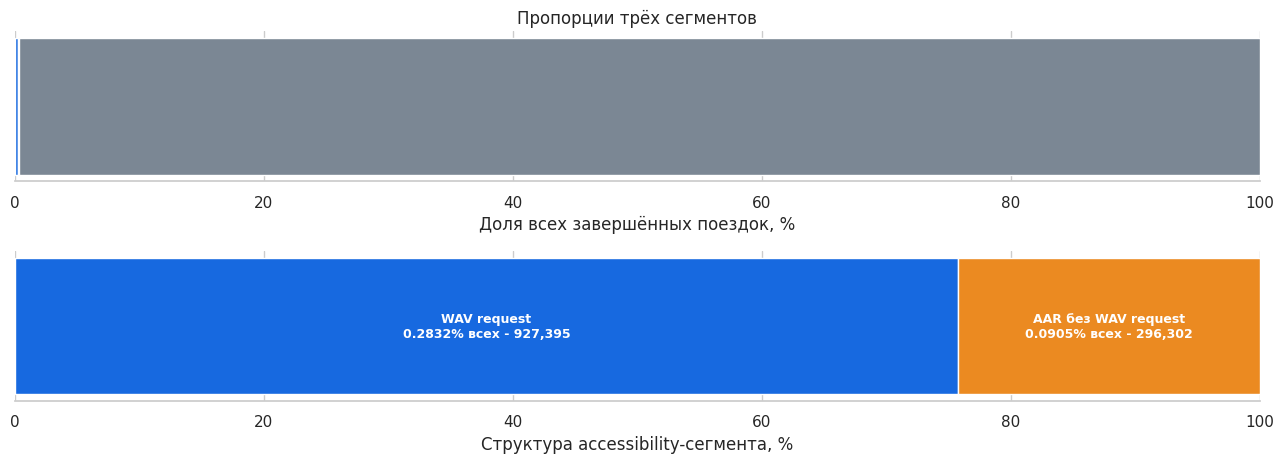

In [7]:
access_counts = (
    date_hour.groupby('accessibility_segment', as_index=False)['trips'].sum()
    .rename(columns={'accessibility_segment': 'сегмент', 'trips': 'поездки'})
)
access_counts['доля, %'] = 100 * access_counts['поездки'] / access_counts['поездки'].sum()
access_counts['сегмент'] = pd.Categorical(
    access_counts['сегмент'], categories=ACCESS_ORDER, ordered=True
)
access_counts = access_counts.sort_values('сегмент').reset_index(drop=True)
display(
    access_counts.style
    .format({'поездки': '{:,.0f}', 'доля, %': '{:.4f}'})
    .hide(axis='index')
)

fig, axes = plt.subplots(2, 1, figsize=(13, 4.8), gridspec_kw={'height_ratios': [1, 1]})
left = 0
for _, row in access_counts.iterrows():
    axes[0].barh(0, row['доля, %'], left=left, color=ACCESS_COLORS[str(row['сегмент'])])
    left += row['доля, %']
axes[0].set_xlim(0, 100)
axes[0].set_yticks([])
axes[0].set_xlabel('Доля всех завершённых поездок, %')
axes[0].set_title('Пропорции трёх сегментов')

access_only = access_counts[access_counts['сегмент'] != 'Остальные'].copy()
access_only['доля внутри accessibility, %'] = 100 * access_only['поездки'] / access_only['поездки'].sum()
left = 0
for _, row in access_only.iterrows():
    width = row['доля внутри accessibility, %']
    axes[1].barh(0, width, left=left, color=ACCESS_COLORS[str(row['сегмент'])])
    axes[1].text(
        left + width / 2, 0,
        f"{row['сегмент']}\n{row['доля, %']:.4f}% всех - {row['поездки']:,.0f}",
        ha='center', va='center', color='white', fontsize=9, weight='bold',
    )
    left += width
axes[1].set_xlim(0, 100)
axes[1].set_yticks([])
axes[1].set_xlabel('Структура accessibility-сегмента, %')
sns.despine(fig=fig, left=True)
plt.tight_layout()
plt.show()

access_total = access_only['поездки'].sum()
access_share = 100 * access_total / access_counts['поездки'].sum()

## 4. Реализованный спрос и доли в динамике

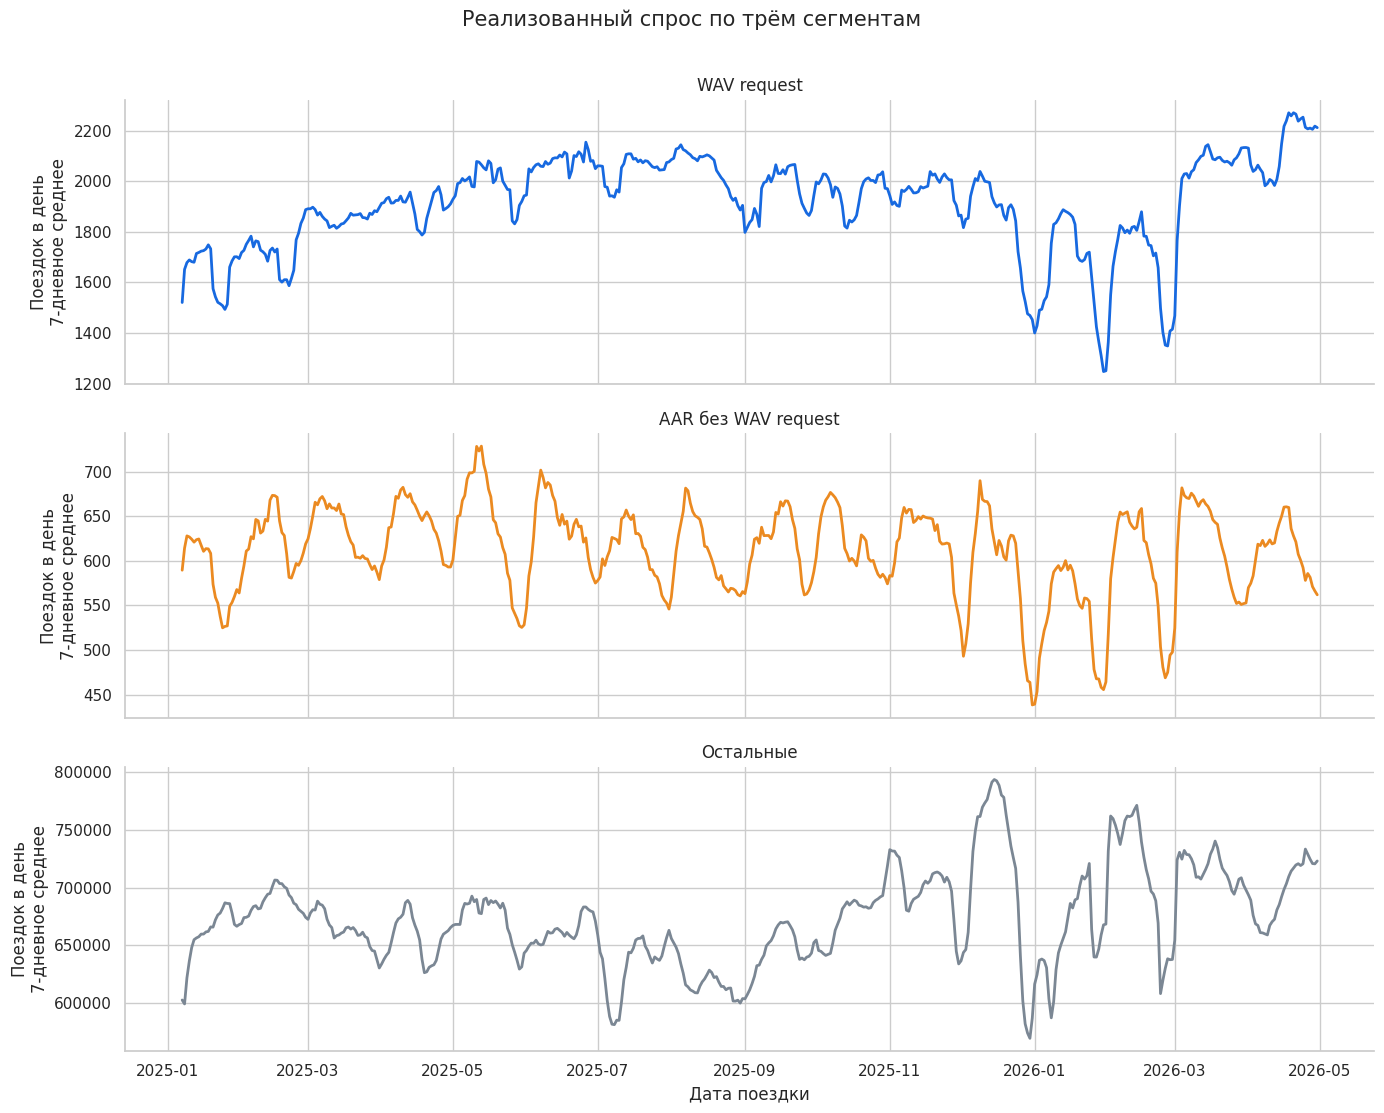

In [8]:
daily = (
    date_hour.groupby(['date', 'accessibility_segment'], as_index=False)['trips'].sum()
    .pivot(index='date', columns='accessibility_segment', values='trips')
    .reindex(columns=ACCESS_ORDER)
    .fillna(0)
)
daily_ma7 = daily.rolling(7, min_periods=7).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, segment in zip(axes, ACCESS_ORDER):
    ax.plot(daily_ma7.index, daily_ma7[segment], color=ACCESS_COLORS[segment], lw=2)
    ax.set_title(segment)
    ax.set_ylabel('Поездок в день\n7-дневное среднее')
    ax.ticklabel_format(axis='y', style='plain')
    sns.despine(ax=ax)
axes[-1].set_xlabel('Дата поездки')
fig.suptitle('Реализованный спрос по трём сегментам', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

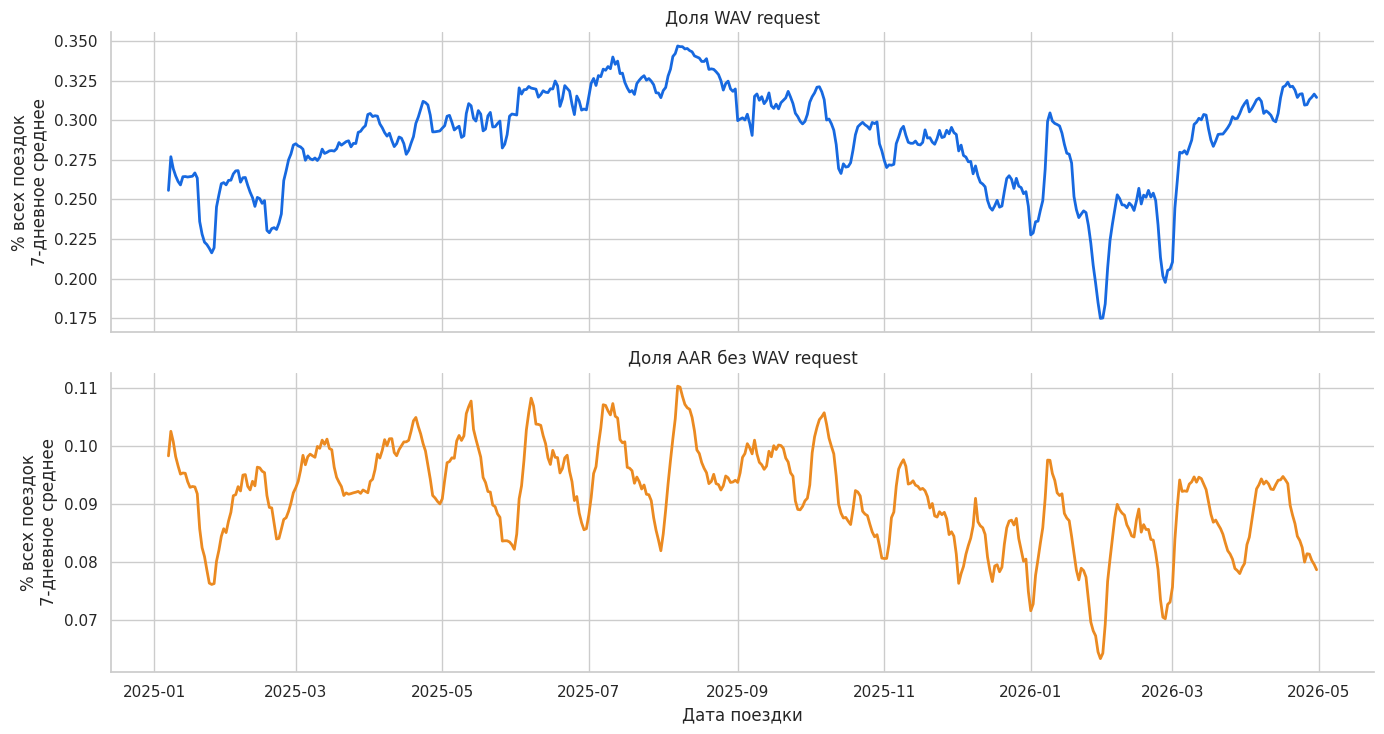

**Вывод.** На последнюю доступную дату сглаженная доля WAV request составляет 0.3144%, AAR без WAV request - 0.0787%.

In [9]:
daily_share = 100 * daily.div(daily.sum(axis=1), axis=0)
daily_share_ma7 = daily_share.rolling(7, min_periods=7).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)
for ax, segment in zip(axes, ACCESS_ORDER[:2]):
    ax.plot(daily_share_ma7.index, daily_share_ma7[segment], color=ACCESS_COLORS[segment], lw=2)
    ax.set_title(f'Доля {segment}')
    ax.set_ylabel('% всех поездок\n7-дневное среднее')
    sns.despine(ax=ax)
axes[-1].set_xlabel('Дата поездки')
plt.tight_layout()
plt.show()

latest_share = daily_share_ma7.dropna().iloc[-1]
display(Markdown(
    f"**Вывод.** На последнюю доступную дату сглаженная доля WAV request составляет "
    f"{latest_share['WAV request']:.4f}%, AAR без WAV request - "
    f"{latest_share['AAR без WAV request']:.4f}%."
))

## 5. Последний месяц и сравнение год к году

In [10]:
monthly_all = monthly[(monthly['provider'] == 'Все') & monthly['month'].notna()].copy()
latest_month = monthly_all['month'].max()
previous_year_month = latest_month - pd.DateOffset(years=1)

latest_frame = monthly_all[monthly_all['month'] == latest_month].set_index('accessibility_segment')
previous_frame = monthly_all[monthly_all['month'] == previous_year_month].set_index('accessibility_segment')
latest_total = latest_frame['trips'].sum()
previous_total = previous_frame['trips'].sum()

yoy_rows = []
for segment in ACCESS_ORDER[:2]:
    n_latest = latest_frame.loc[segment, 'trips']
    n_previous = previous_frame.loc[segment, 'trips']
    share_latest = 100 * n_latest / latest_total
    share_previous = 100 * n_previous / previous_total
    yoy_rows.append({
        'сегмент': segment,
        f'поездки {latest_month:%Y-%m}': n_latest,
        f'поездки {previous_year_month:%Y-%m}': n_previous,
        'изменение количества, %': 100 * (n_latest / n_previous - 1),
        f'доля {latest_month:%Y-%m}, %': share_latest,
        f'доля {previous_year_month:%Y-%m}, %': share_previous,
        'изменение доли, п.п.': share_latest - share_previous,
    })
yoy_table = pd.DataFrame(yoy_rows)
display(
    yoy_table.style
    .format({
        f'поездки {latest_month:%Y-%m}': '{:,.0f}',
        f'поездки {previous_year_month:%Y-%m}': '{:,.0f}',
        'изменение количества, %': '{:+.2f}',
        f'доля {latest_month:%Y-%m}, %': '{:.4f}',
        f'доля {previous_year_month:%Y-%m}, %': '{:.4f}',
        'изменение доли, п.п.': '{:+.4f}',
    })
    .hide(axis='index')
)

сегмент,поездки 2026-04,поездки 2025-04,"изменение количества, %","доля 2026-04, %","доля 2025-04, %","изменение доли, п.п."
WAV request,"65,246","57,865",+12.76,0.3108,0.2929,+0.0178
AAR без WAV request,"18,420","19,339",-4.75,0.0877,0.0979,-0.0102


## 6. Доля WAV-мэтчей среди завершённых WAV requests

In [11]:
match_monthly = monthly_all[
    monthly_all['accessibility_segment'] == 'WAV request'
][['month', 'wav_request_n', 'wav_match_n']].copy()
match_monthly['доля WAV-мэтчей, %'] = (
    100 * match_monthly['wav_match_n'] / match_monthly['wav_request_n']
)
match_table = match_monthly.rename(columns={
    'month': 'месяц',
    'wav_request_n': 'завершённые WAV requests',
    'wav_match_n': 'WAV-мэтчи',
})
display(
    match_table.style
    .format({
        'месяц': lambda x: f'{x:%Y-%m}',
        'завершённые WAV requests': '{:,.0f}',
        'WAV-мэтчи': '{:,.0f}',
        'доля WAV-мэтчей, %': '{:.3f}',
    })
    .hide(axis='index')
)

месяц,завершённые WAV requests,WAV-мэтчи,"доля WAV-мэтчей, %"
2025-01,"51,150","51,150",100.000
2025-02,"48,832","48,832",100.000
2025-03,"56,494","56,491",99.995
2025-04,"57,865","57,863",99.997
2025-05,"61,871","61,870",99.998
2025-06,"61,917","61,917",100.000
2025-07,"64,302","64,302",100.000
2025-08,"62,289","62,287",99.997
2025-09,"59,209","59,209",100.000
2025-10,"61,208","61,205",99.995


## 7. Время подачи и посадки

Время подачи - `request_datetime → on_scene_datetime`. Время посадки - `on_scene_datetime → pickup_datetime`. В расчёт входят только записи с корректной хронологией. Покрытие `on_scene` показывается отдельно, потому что оно различается между сегментами.

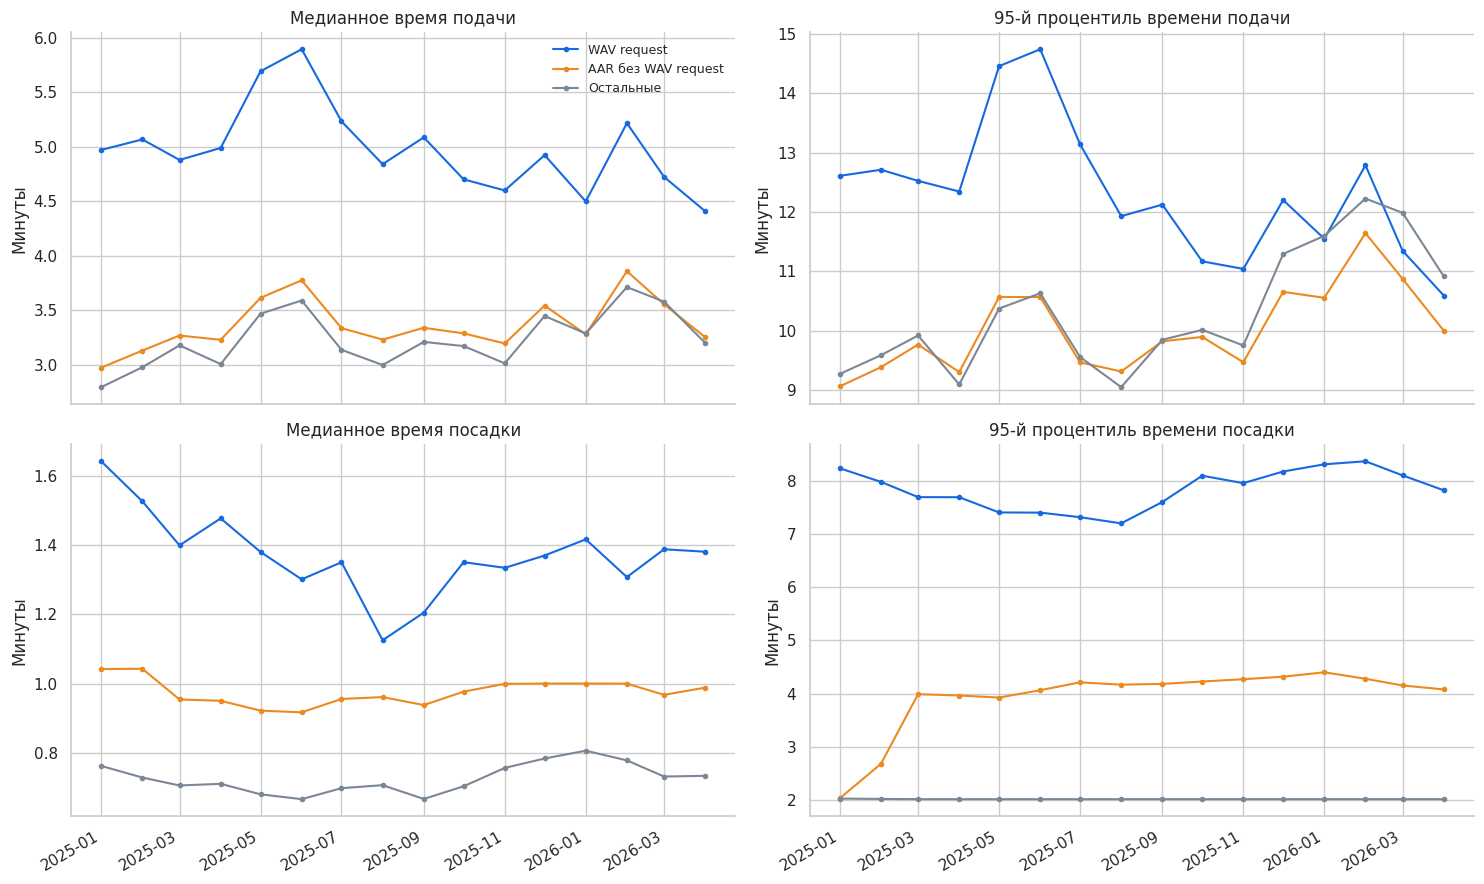

сегмент,поездки,валидное время подачи,валидное время посадки,"покрытие времени подачи, %","покрытие времени посадки, %"
AAR без WAV request,"18,420","18,382","18,420",99.79,100.00
WAV request,"65,246","49,606","65,246",76.03,100.00
Остальные,"20,912,248","20,565,806","20,911,584",98.34,100.00


In [12]:
def plot_monthly_lines(frame, metrics, titles, ylabel, figsize=(15, 9)):
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
    for ax, metric, title in zip(axes.flat, metrics, titles):
        for segment in ACCESS_ORDER:
            rows = frame[frame['accessibility_segment'] == segment].sort_values('month')
            ax.plot(
                rows['month'], rows[metric], marker='o', ms=3,
                color=ACCESS_COLORS[segment], label=segment,
            )
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        sns.despine(ax=ax)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

plot_monthly_lines(
    monthly_all,
    ['arrival_p50_min', 'arrival_p95_min', 'boarding_p50_min', 'boarding_p95_min'],
    [
        'Медианное время подачи', '95-й процентиль времени подачи',
        'Медианное время посадки', '95-й процентиль времени посадки',
    ],
    'Минуты',
)

coverage_latest = latest_frame.reset_index()[[
    'accessibility_segment', 'trips', 'arrival_n', 'boarding_n'
]].copy()
coverage_latest['покрытие времени подачи, %'] = 100 * coverage_latest['arrival_n'] / coverage_latest['trips']
coverage_latest['покрытие времени посадки, %'] = 100 * coverage_latest['boarding_n'] / coverage_latest['trips']
coverage_latest = coverage_latest.rename(columns={
    'accessibility_segment': 'сегмент', 'trips': 'поездки',
    'arrival_n': 'валидное время подачи', 'boarding_n': 'валидное время посадки',
})
display(
    coverage_latest.style
    .format({
        'поездки': '{:,.0f}', 'валидное время подачи': '{:,.0f}',
        'валидное время посадки': '{:,.0f}',
        'покрытие времени подачи, %': '{:.2f}',
        'покрытие времени посадки, %': '{:.2f}',
    })
    .hide(axis='index')
)

## 8. Стоимость и параметры поездки

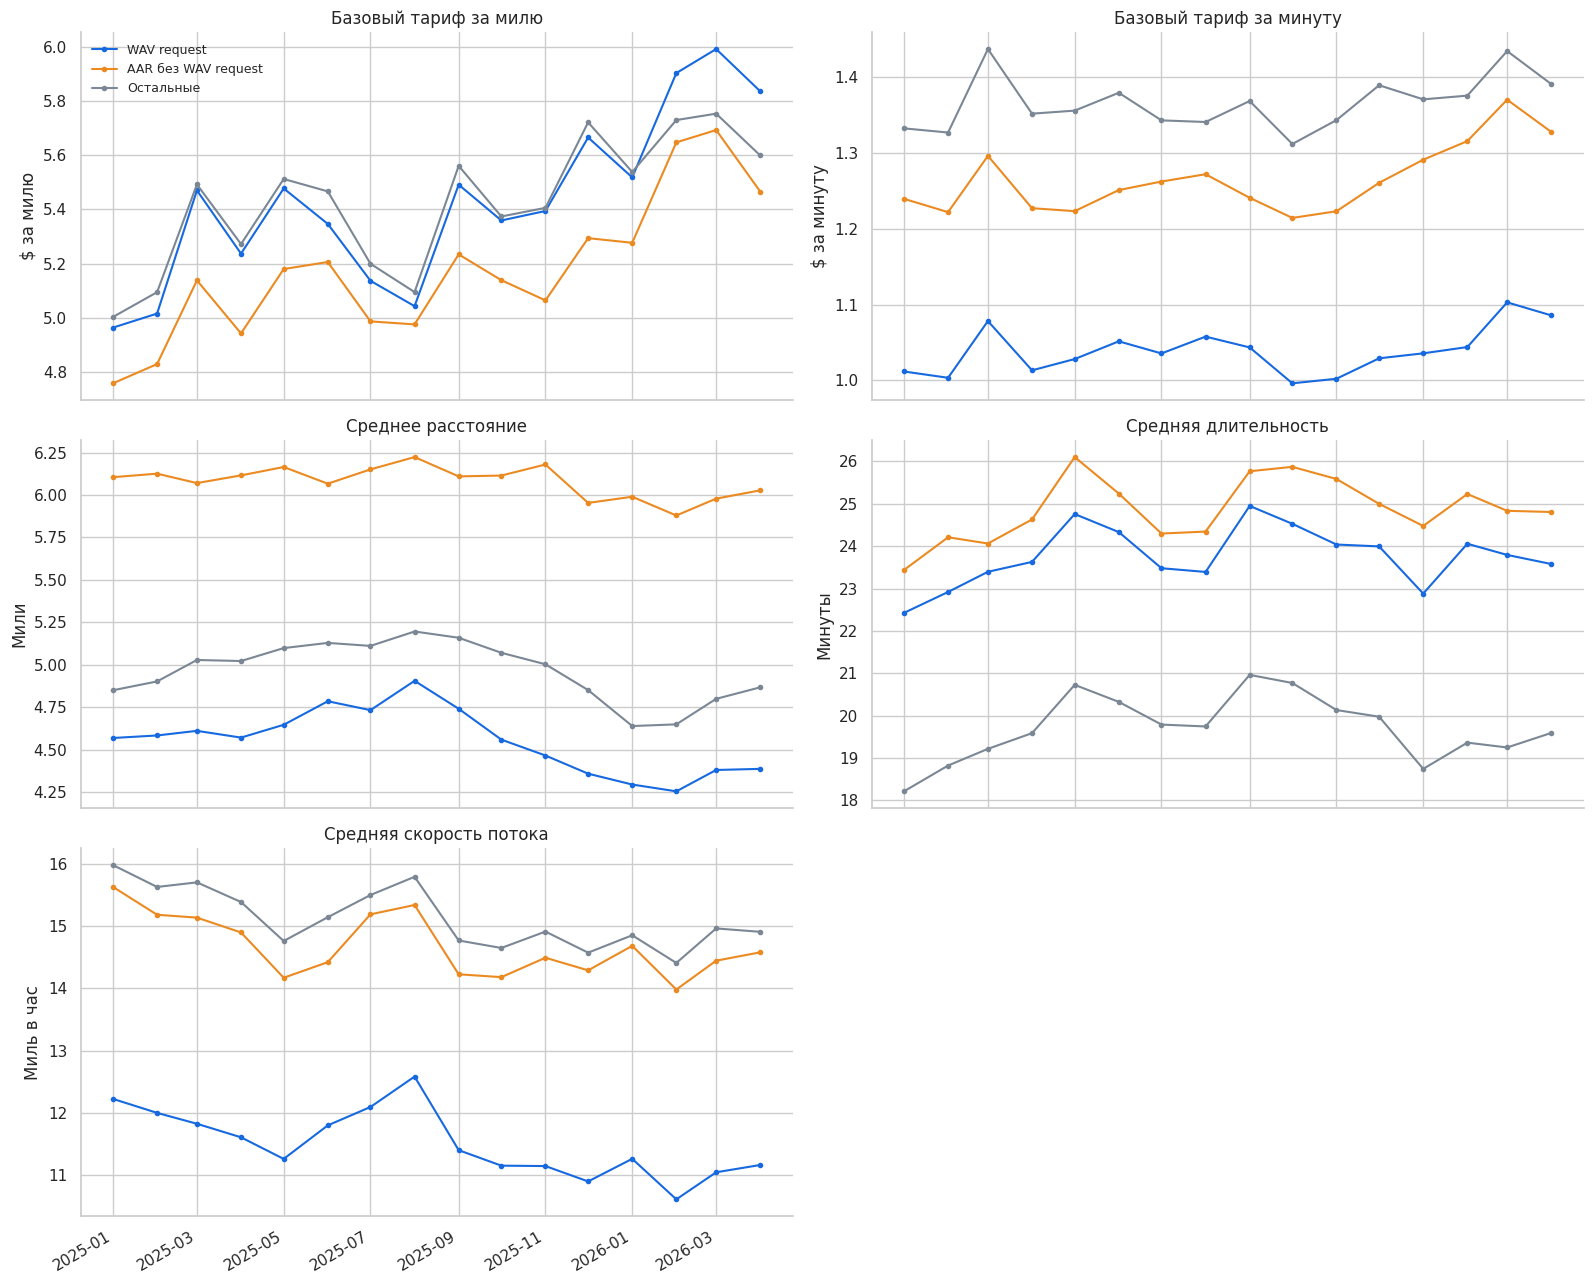

In [13]:
economics_metrics = [
    ('base_fare_per_mile', 'Базовый тариф за милю', '$ за милю'),
    ('base_fare_per_min', 'Базовый тариф за минуту', '$ за минуту'),
    ('mean_miles', 'Среднее расстояние', 'Мили'),
    ('mean_duration_min', 'Средняя длительность', 'Минуты'),
    ('aggregate_speed_mph', 'Средняя скорость потока', 'Миль в час'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)
for ax, (metric, title, ylabel) in zip(axes.flat, economics_metrics):
    for segment in ACCESS_ORDER:
        rows = monthly_all[monthly_all['accessibility_segment'] == segment].sort_values('month')
        ax.plot(
            rows['month'], rows[metric], marker='o', ms=3,
            color=ACCESS_COLORS[segment], label=segment,
        )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)
axes[0, 0].legend(frameon=False, fontsize=9)
axes[-1, -1].axis('off')
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

Базовый тариф нормирован одновременно на расстояние и длительность, поскольку средний маршрут сегментов различается. Скорость рассчитана как отношение суммарных миль к суммарному времени и потому взвешена длительностью поездок.

## 9. Чаевые

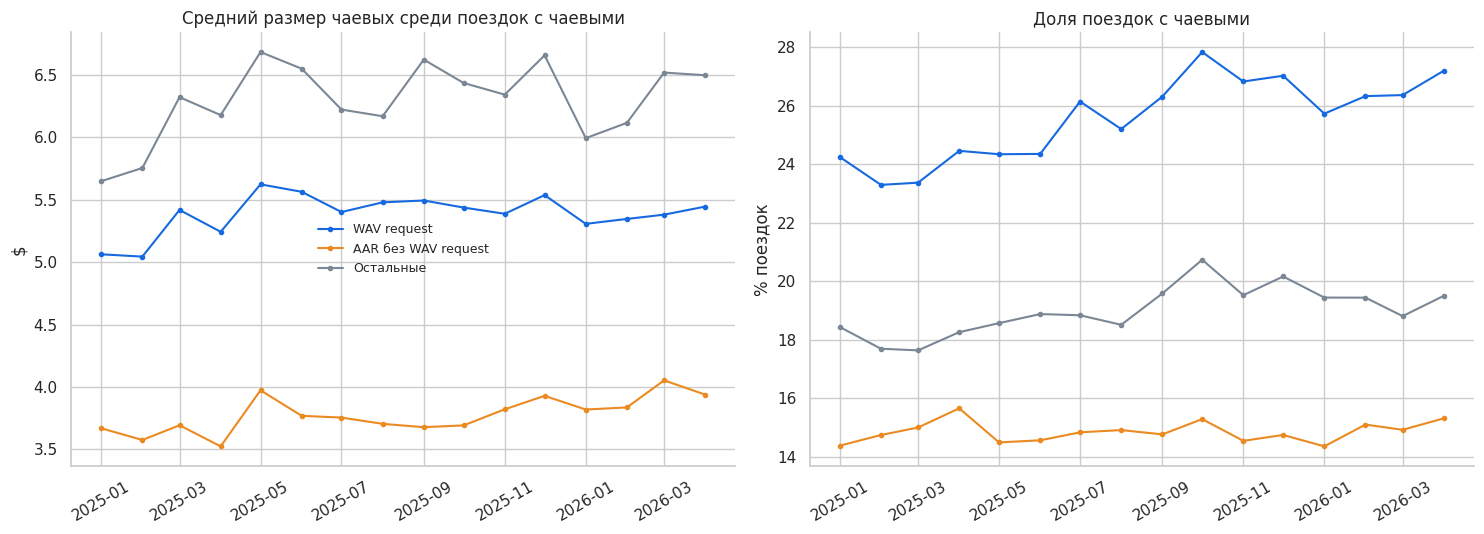

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
for segment in ACCESS_ORDER:
    rows = monthly_all[monthly_all['accessibility_segment'] == segment].sort_values('month')
    axes[0].plot(
        rows['month'], rows['mean_tip_positive'], marker='o', ms=3,
        color=ACCESS_COLORS[segment], label=segment,
    )
    axes[1].plot(
        rows['month'], rows['tipped_share_pct'], marker='o', ms=3,
        color=ACCESS_COLORS[segment], label=segment,
    )
axes[0].set_title('Средний размер чаевых среди поездок с чаевыми')
axes[0].set_ylabel('$')
axes[1].set_title('Доля поездок с чаевыми')
axes[1].set_ylabel('% поездок')
axes[0].legend(frameon=False, fontsize=9)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Размер чаевых считается только среди положительных значений, а доля - среди всех поездок с корректными финансовыми полями.

## 10. Uber и Lyft

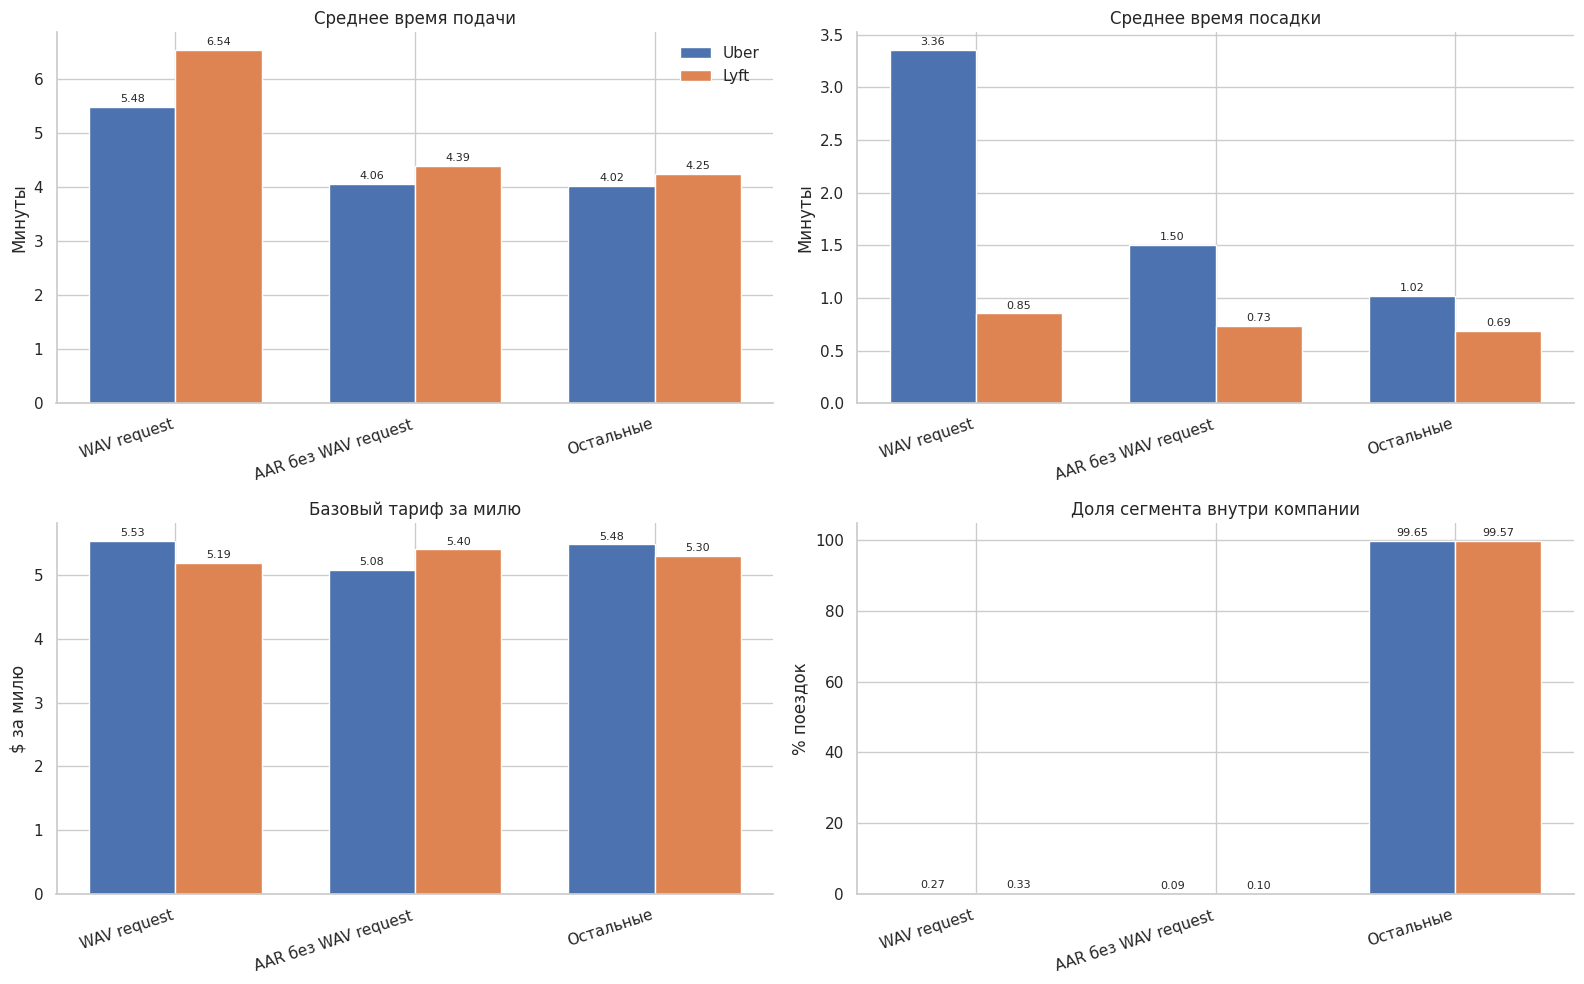

компания,сегмент,поездки,время подачи n,посадка n,финансы n,"покрытие подачи, %","покрытие посадки, %"
Lyft,AAR без WAV request,"91,014","77,599","78,575","91,010",85.26,86.33
Lyft,WAV request,"296,209","136,966","296,209","296,099",46.24,100.00
Lyft,Остальные,"90,331,976","78,202,410","79,473,958","90,327,621",86.57,87.98
Uber,AAR без WAV request,"205,288","205,274","205,284","205,251",99.99,100.00
Uber,WAV request,"631,186","606,572","631,183","630,429",96.10,100.00
Uber,Остальные,"235,890,634","232,323,386","235,834,183","235,801,337",98.49,99.98


In [15]:
provider_overall = monthly[
    monthly['month'].isna() & monthly['provider'].isin(['Uber', 'Lyft'])
].copy()
provider_overall['доля сегмента внутри компании, %'] = (
    100 * provider_overall['trips']
    / provider_overall.groupby('provider')['trips'].transform('sum')
)

provider_metrics = [
    ('arrival_mean_min', 'Среднее время подачи', 'Минуты'),
    ('boarding_mean_min', 'Среднее время посадки', 'Минуты'),
    ('base_fare_per_mile', 'Базовый тариф за милю', '$ за милю'),
    ('доля сегмента внутри компании, %', 'Доля сегмента внутри компании', '% поездок'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(ACCESS_ORDER))
width = 0.36
for ax, (metric, title, ylabel) in zip(axes.flat, provider_metrics):
    for i, provider in enumerate(['Uber', 'Lyft']):
        rows = (
            provider_overall[provider_overall['provider'] == provider]
            .set_index('accessibility_segment')
            .reindex(ACCESS_ORDER)
        )
        values_plot = rows[metric].to_numpy()
        bars = ax.bar(x + (i - 0.5) * width, values_plot, width, label=provider)
        ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, ACCESS_ORDER, rotation=18, ha='right')
    sns.despine(ax=ax)
axes[0, 0].legend(frameon=False)
plt.tight_layout()
plt.show()

provider_table = provider_overall[[
    'provider', 'accessibility_segment', 'trips',
    'arrival_n', 'boarding_n', 'economics_n',
]].copy()
provider_table['покрытие подачи, %'] = 100 * provider_table['arrival_n'] / provider_table['trips']
provider_table['покрытие посадки, %'] = 100 * provider_table['boarding_n'] / provider_table['trips']
display(
    provider_table.rename(columns={
        'provider': 'компания', 'accessibility_segment': 'сегмент',
        'trips': 'поездки', 'arrival_n': 'время подачи n',
        'boarding_n': 'посадка n', 'economics_n': 'финансы n',
    }).style.format({
        'поездки': '{:,.0f}', 'время подачи n': '{:,.0f}',
        'посадка n': '{:,.0f}', 'финансы n': '{:,.0f}',
        'покрытие подачи, %': '{:.2f}', 'покрытие посадки, %': '{:.2f}',
    }).hide(axis='index')
)

## 11. Сезонность: день недели и час

В каждой ячейке показана доля недельного объёма соответствующего сегмента. Нормирование внутри сегмента делает формы спроса сопоставимыми при большой разнице абсолютных объёмов.

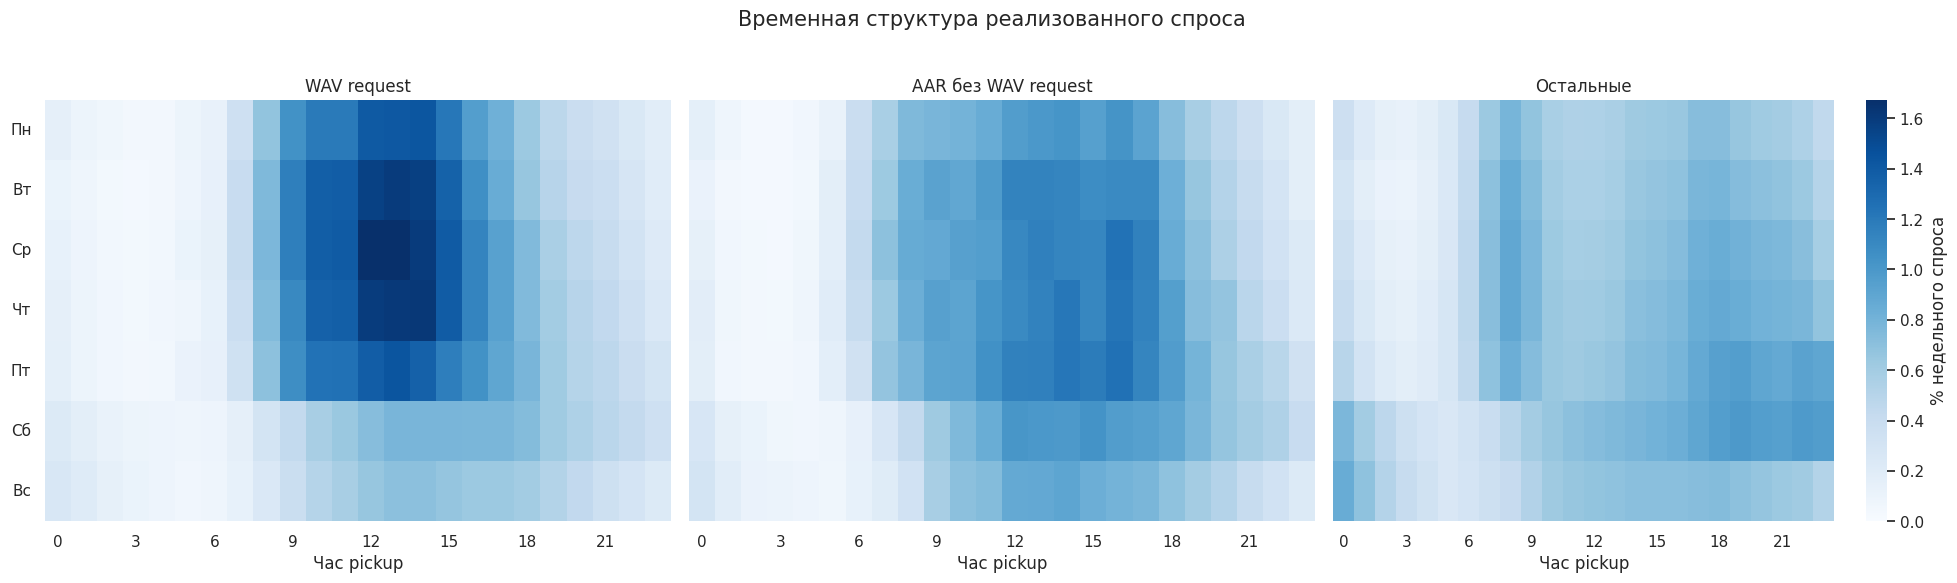

сегмент,"будни 09:00-16:59, %","выходные, %","00:00-05:59, %"
WAV request,53.51,20.03,4.10
AAR без WAV request,41.85,25.00,4.26
Остальные,26.24,30.56,12.62


In [16]:
seasonality = date_hour.copy()
seasonality['день недели'] = seasonality['date'].dt.dayofweek
seasonality = (
    seasonality.groupby(['accessibility_segment', 'день недели', 'hour'], as_index=False)['trips'].sum()
)
seasonality['доля недельного спроса, %'] = (
    100 * seasonality['trips']
    / seasonality.groupby('accessibility_segment')['trips'].transform('sum')
)
vmax = seasonality['доля недельного спроса, %'].max()
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.7), sharey=True)
for ax, segment in zip(axes, ACCESS_ORDER):
    pivot = (
        seasonality[seasonality['accessibility_segment'] == segment]
        .pivot(index='день недели', columns='hour', values='доля недельного спроса, %')
        .reindex(index=range(7), columns=range(24))
    )
    sns.heatmap(
        pivot, ax=ax, cmap='Blues', vmin=0, vmax=vmax,
        cbar=ax is axes[-1],
        cbar_kws={'label': '% недельного спроса'},
        xticklabels=3, yticklabels=day_labels,
    )
    ax.set_title(segment)
    ax.set_xlabel('Час pickup')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)
fig.suptitle('Временная структура реализованного спроса', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

def period_share(segment, mask):
    frame = date_hour[date_hour['accessibility_segment'] == segment]
    return 100 * frame.loc[mask(frame), 'trips'].sum() / frame['trips'].sum()

seasonality_summary = pd.DataFrame({
    'сегмент': ACCESS_ORDER,
    'будни 09:00-16:59, %': [
        period_share(s, lambda x: (x['date'].dt.dayofweek < 5) & x['hour'].between(9, 16))
        for s in ACCESS_ORDER
    ],
    'выходные, %': [
        period_share(s, lambda x: x['date'].dt.dayofweek >= 5)
        for s in ACCESS_ORDER
    ],
    '00:00-05:59, %': [
        period_share(s, lambda x: x['hour'].between(0, 5))
        for s in ACCESS_ORDER
    ],
})
display(
    seasonality_summary.style
    .format({
        'будни 09:00-16:59, %': '{:.2f}',
        'выходные, %': '{:.2f}',
        '00:00-05:59, %': '{:.2f}',
    })
    .hide(axis='index')
)

wav_time = seasonality_summary.iloc[0]
other_time = seasonality_summary.iloc[2]

Вывод. В будни с 09:00 до 16:59 происходит 53.5% WAV request поездок против 26.2% остальных. Тепловые карты показывают устойчивое различие формы спроса, которое следует учитывать при планировании доступного предложения по сменам.

## 12. География pickup и dropoff

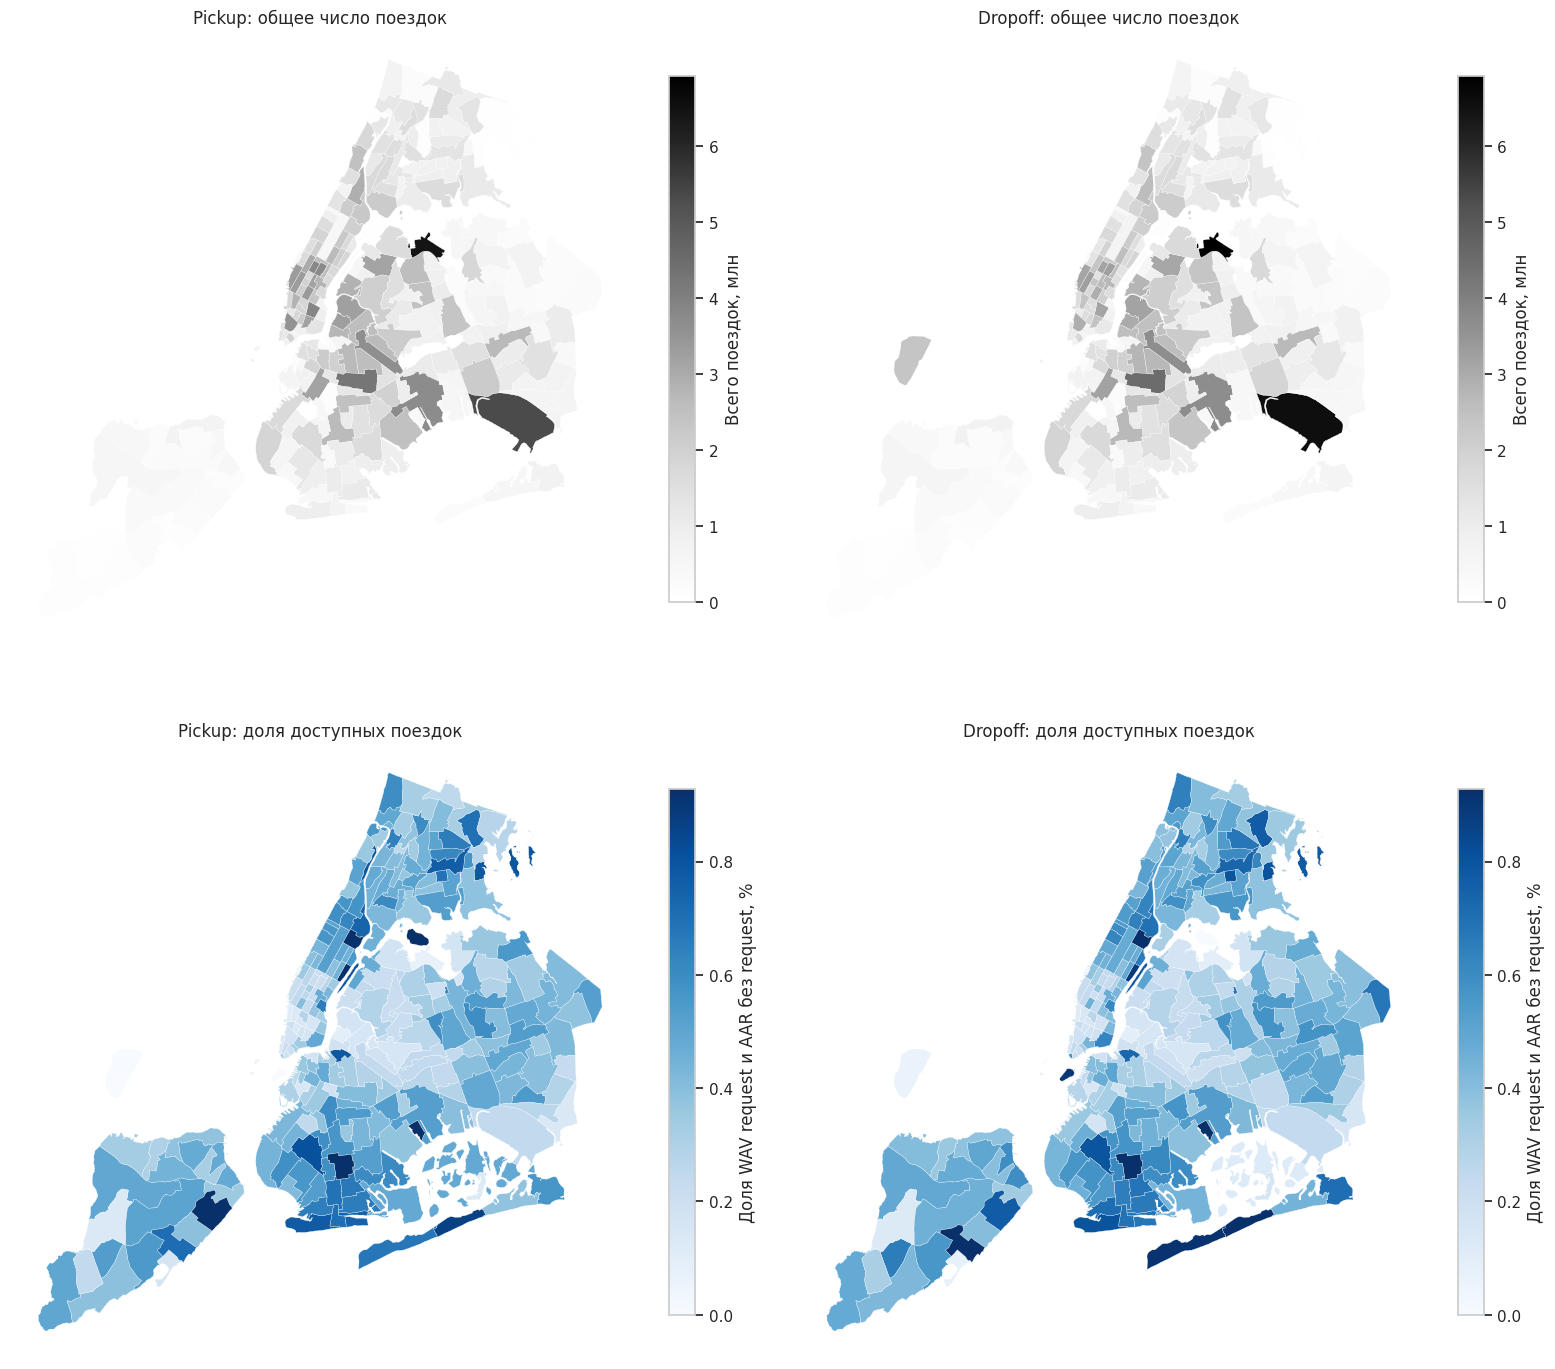

направление,зона,боро,всего поездок,доступные поездки,"доля доступных, %"
Pickup,East Harlem South,Manhattan,"2,018,650","20,427",1.012
Pickup,East New York,Brooklyn,"3,732,862","19,677",0.527
Pickup,Lenox Hill East,Manhattan,"1,820,545","17,450",0.959
Pickup,Crown Heights North,Brooklyn,"4,259,497","17,390",0.408
Pickup,East Harlem North,Manhattan,"2,266,652","16,783",0.740
Pickup,Central Harlem North,Manhattan,"2,903,974","16,565",0.570
Pickup,Flatbush/Ditmas Park,Brooklyn,"2,636,507","14,890",0.565
Pickup,Borough Park,Brooklyn,"1,705,907","13,842",0.811
Pickup,Prospect-Lefferts Gardens,Brooklyn,"2,488,798","13,450",0.540
Pickup,Central Harlem,Manhattan,"2,123,884","13,294",0.626


In [17]:
zip_source = f'/vsizip/{ZONE_ZIP_PATH.resolve().as_posix()}/taxi_zones/taxi_zones.shp'
zones = gpd.read_file(zip_source)[['LocationID', 'borough', 'zone', 'geometry']]
zones['LocationID'] = zones['LocationID'].astype(int)

geo_frames = {}
for direction in ['Pickup', 'Dropoff']:
    metrics = zone_metrics[zone_metrics['direction'] == direction].copy()
    geo = zones.merge(metrics, on='LocationID', how='left')
    geo['total_trips_mln'] = geo['total_trips'] / 1_000_000
    geo_frames[direction] = geo

count_max = max(frame['total_trips_mln'].max() for frame in geo_frames.values())
share_max = max(frame['accessibility_share_pct'].quantile(0.98) for frame in geo_frames.values())

fig, axes = plt.subplots(2, 2, figsize=(16, 15))
for col, direction in enumerate(['Pickup', 'Dropoff']):
    geo = geo_frames[direction]
    geo.plot(
        column='total_trips_mln', ax=axes[0, col], cmap='Greys',
        vmin=0, vmax=count_max, legend=True,
        legend_kwds={'label': 'Всего поездок, млн', 'shrink': 0.7},
        linewidth=0.2, edgecolor='white', missing_kwds={'color': '#eeeeee'},
    )
    axes[0, col].set_title(f'{direction}: общее число поездок')
    geo.plot(
        column='accessibility_share_pct', ax=axes[1, col], cmap='Blues',
        vmin=0, vmax=share_max, legend=True,
        legend_kwds={'label': 'Доля WAV request и AAR без request, %', 'shrink': 0.7},
        linewidth=0.2, edgecolor='white', missing_kwds={'color': '#eeeeee'},
    )
    axes[1, col].set_title(f'{direction}: доля доступных поездок')
for ax in axes.flat:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

top_zone_rows = []
for direction, geo in geo_frames.items():
    valid = geo.dropna(subset=['total_trips', 'accessibility_share_pct']).copy()
    for _, row in valid.nlargest(10, 'accessibility_trips').iterrows():
        top_zone_rows.append({
            'направление': direction,
            'зона': row['zone'],
            'боро': row['borough'],
            'всего поездок': row['total_trips'],
            'доступные поездки': row['accessibility_trips'],
            'доля доступных, %': row['accessibility_share_pct'],
        })
top_zones = pd.DataFrame(top_zone_rows)
display(
    top_zones.style
    .format({
        'всего поездок': '{:,.0f}', 'доступные поездки': '{:,.0f}',
        'доля доступных, %': '{:.3f}',
    })
    .hide(axis='index')
)


## 13. Аналитическое саммари

1. Accessibility-сегмент мал относительно всего рынка. WAV request и AAR без WAV request вместе дают 0.3737% завершённых поездок.
2. Спрос на доступные поездки сильнее сконцентрирован в рабочее дневное время. В будни с 09:00 до 16:59 происходит 53.5% WAV request поездок против 26.2% остальных. Это аргумент в пользу отдельного планирования WAV supply по сменам, а не пропорционального распределения по общему спросу.
4. Доля WAV-мэтчей не равна fulfilment rate. В 2026-04 WAV-мэтч отмечен в 100.000% завершённых WAV requests. Отменённые и невыполненные запросы в TLC trip records отсутствуют.